<a href="https://colab.research.google.com/github/nhuwynh07/THDeepLearning/blob/main/DL_Tuan03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Bước 1: Import các thư viện cần thiết
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np


In [13]:
# Bước 2: Load dataset MNIST
# x_train: ảnh dùng để huấn luyện
# y_train: nhãn của ảnh huấn luyện
# x_test: ảnh dùng để kiểm tra
# y_test: nhãn của ảnh kiểm tra
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# In kích thước dữ liệu
print("Kích thước x_train:", x_train.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước x_test:", x_test.shape)
print("Kích thước y_test:", y_test.shape)


Kích thước x_train: (60000, 28, 28)
Kích thước y_train: (60000,)
Kích thước x_test: (10000, 28, 28)
Kích thước y_test: (10000,)


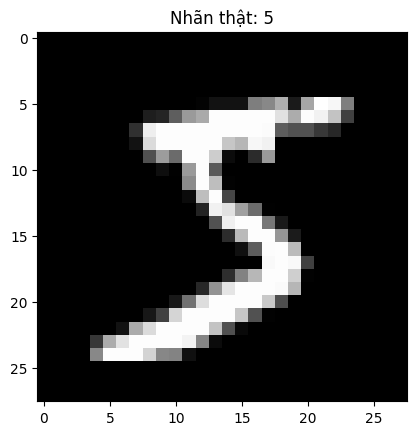

In [14]:
# Bước 3: Hiển thị thử một ảnh trong dataset
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Nhãn thật: {y_train[0]}")
plt.show()

In [15]:
# Bước 4: Tiền xử lý dữ liệu
# Giá trị pixel ban đầu nằm trong khoảng 0 đến 255
# Ta chia cho 255 để đưa về khoảng 0 đến 1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [16]:
# Bước 5: Xây dựng mô hình ANN
model = keras.Sequential([
    # Chuyển ảnh 28x28 thành vector 784
    layers.Flatten(input_shape=(28, 28)),

    # Lớp ẩn thứ nhất gồm 128 neuron
    layers.Dense(128, activation='relu'),

    # Lớp ẩn thứ hai gồm 64 neuron
    layers.Dense(64, activation='relu'),

    # Lớp output gồm 10 neuron tương ứng với 10 chữ số 0-9
    layers.Dense(10, activation='softmax')
])

In [17]:
# Bước 6: Compile mô hình
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Hiển thị cấu trúc mô hình
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Bước 7: Huấn luyện mô hình
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9204 - loss: 0.2718 - val_accuracy: 0.9589 - val_loss: 0.1395
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9650 - loss: 0.1156 - val_accuracy: 0.9694 - val_loss: 0.1038
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9752 - loss: 0.0813 - val_accuracy: 0.9679 - val_loss: 0.1145
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9808 - loss: 0.0587 - val_accuracy: 0.9660 - val_loss: 0.1175
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9852 - loss: 0.0469 - val_accuracy: 0.9719 - val_loss: 0.0995
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9882 - loss: 0.0359 - val_accuracy: 0.9741 - val_loss: 0.0987
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9905 - loss: 0.0290 - val_accuracy: 0.9771 - val_loss: 0.0942
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9919 - loss: 0.0247 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9796 - loss: 0.0900
Độ lỗi trên tập test: 0.08999824523925781
Độ chính xác trên tập test: 0.9796000123023987


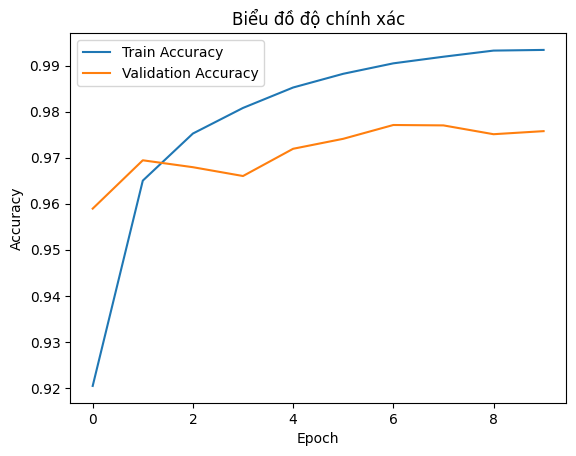

In [19]:
# Bước 8: Đánh giá mô hình trên tập test
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Độ lỗi trên tập test:", test_loss)
print("Độ chính xác trên tập test:", test_accuracy)

# Bước 9: Vẽ biểu đồ accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Biểu đồ độ chính xác')
plt.show()


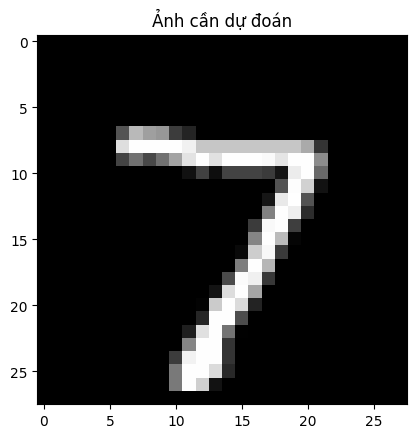

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Nhãn thật: 7
Nhãn dự đoán: 7
Xác suất dự đoán: [[5.9356019e-13 2.4658105e-12 1.7004068e-09 2.0343968e-07 9.7768645e-20
  9.7934681e-14 1.3435842e-16 9.9999976e-01 2.2217323e-13 1.5380615e-11]]


In [20]:
# Bước 10: Dự đoán thử một ảnh
index = 0

plt.imshow(x_test[index], cmap='gray')
plt.title("Ảnh cần dự đoán")
plt.show()

prediction = model.predict(np.array([x_test[index]]))

predicted_label = np.argmax(prediction)

print("Nhãn thật:", y_test[index])
print("Nhãn dự đoán:", predicted_label)
print("Xác suất dự đoán:", prediction)